# #INIT: Этап 2 – Первичная обработка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Настройки графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

In [2]:
# Загрузка
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (442, 11)

Первые 5 строк:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.describe() #NOTE: Минимумы, максимумы, стандартные отклонения

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


>[!WARNING] #TODO:
>
>- #DEEP[tech, context]: `df.describe()`

In [4]:
# Проверка на пропуски (изначально их нет)
print("Пропуски в каждом столбце:")
print(df.isnull().sum())

Пропуски в каждом столбце:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


>#SYSTEMATIZE:ANALYZE_TASK

>## **Цель**:
Распределение целевой переменной (гистограмма + KDE).

Корреляционную матрицу (heatmap).

Scatter-plot признаков vs target (например, для первых 4 признаков) или pairplot.

А также для полиномиальной регрессии — график предсказаний vs истинных значений и кривая MSE от степени полинома. Для кластеризации — метод локтя и PCA-визуализация кластеров.

Text(0, 0.5, 'Частота')

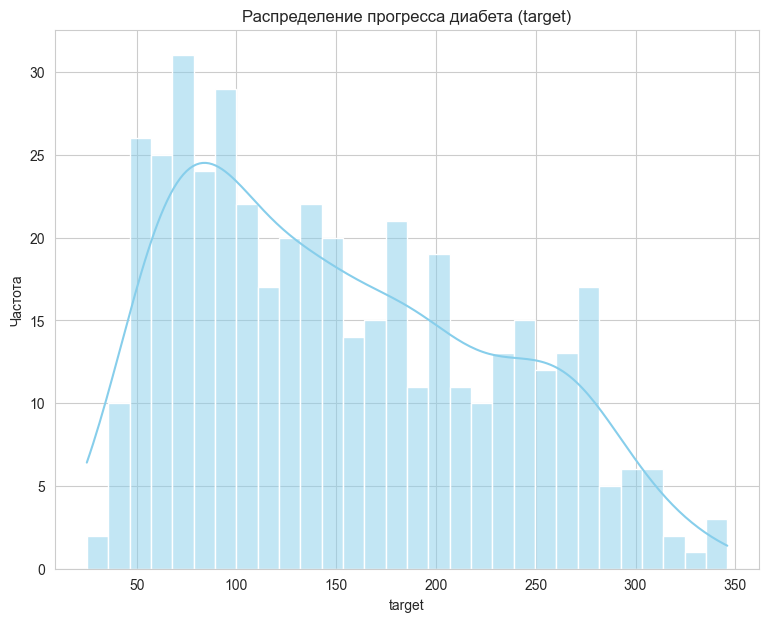

In [5]:
# 1. Распределение целевой переменной
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
sns.histplot(df['target'], bins=30, kde=True, color='skyblue')
plt.title('Распределение прогресса диабета (target)')
plt.xlabel('target')
plt.ylabel('Частота')


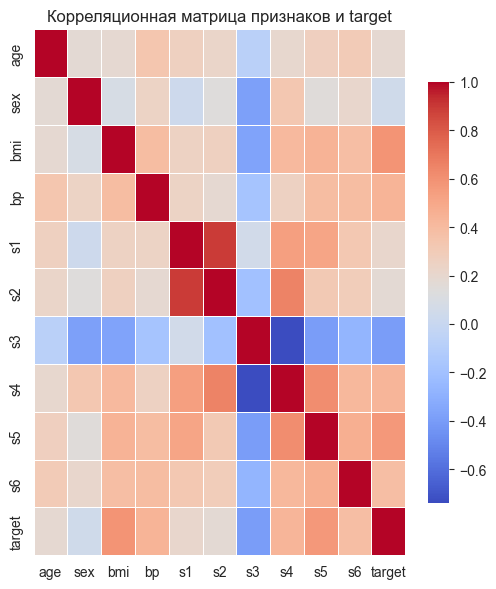

In [6]:
# 2. Корреляционная матрица
plt.subplot(1,2,2)
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Корреляционная матрица признаков и target')
plt.tight_layout()
plt.show()

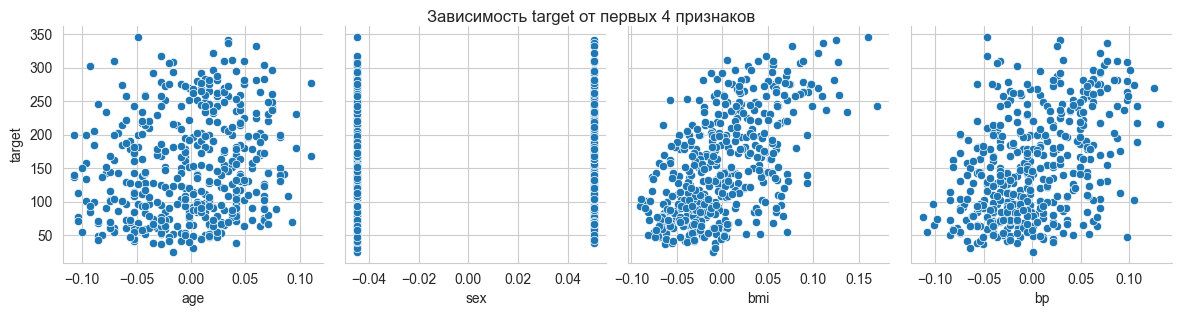

In [7]:
# 3. Парные графики (первые 4 признака vs target)
sns.pairplot(df, x_vars=data.feature_names[:4], y_vars='target', height=3, kind='scatter')
plt.suptitle('Зависимость target от первых 4 признаков', y=1.02)
plt.show()

In [8]:
# #MAKED: Разделение на train/test
X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (353, 10)
Test size: (89, 10)


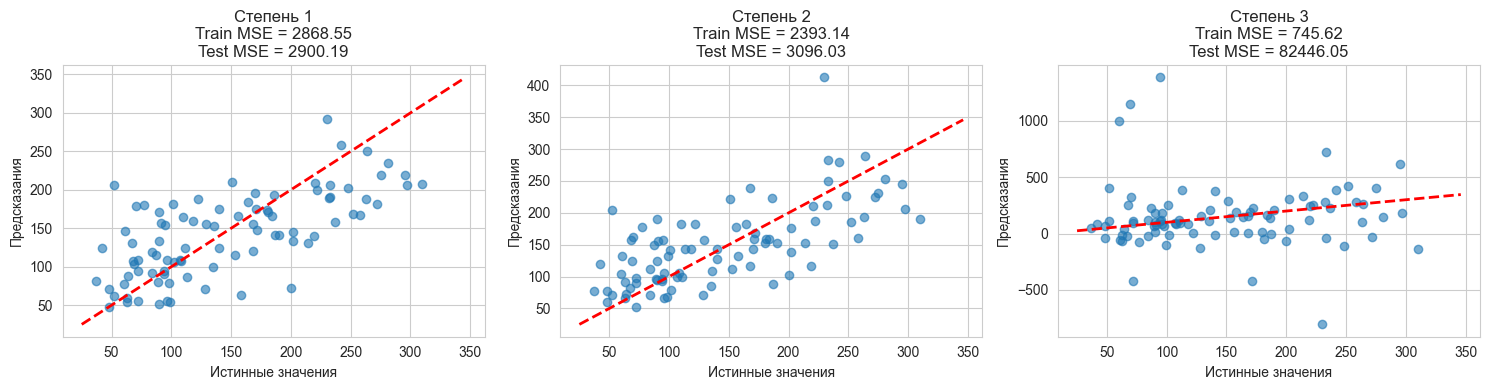

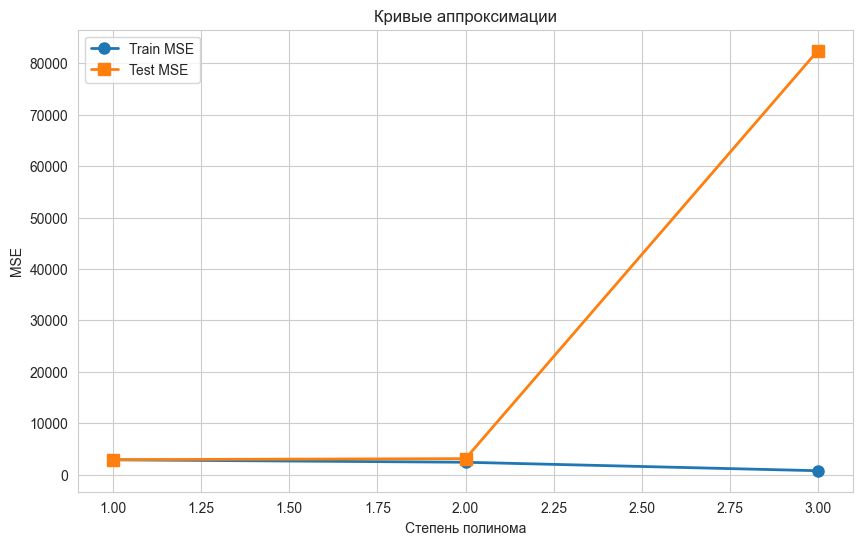

Анализ: степень 2 даёт наименьшую ошибку на тесте, степень 3 переобучается.


In [9]:
# #PROC: Полиномиальная регрессия
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

degrees = [1, 2, 3]
train_mse = []
test_mse = []

plt.figure(figsize=(15, 4))

for i, d in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    train_mse.append(mse_train)
    test_mse.append(mse_test)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, y_test_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказания')
    plt.title(f'Степень {d}\nTrain MSE = {mse_train:.2f}\nTest MSE = {mse_test:.2f}')

plt.tight_layout()
plt.show()

# График зависимости MSE от степени
plt.figure()
plt.plot(degrees, train_mse, 'o-', label='Train MSE', linewidth=2, markersize=8)
plt.plot(degrees, test_mse, 's-', label='Test MSE', linewidth=2, markersize=8)
plt.xlabel('Степень полинома')
plt.ylabel('MSE')
plt.title('Кривые аппроксимации')
plt.legend()
plt.grid(True)
plt.show()

print("Анализ: степень 2 даёт наименьшую ошибку на тесте, степень 3 переобучается.")
#MAKED

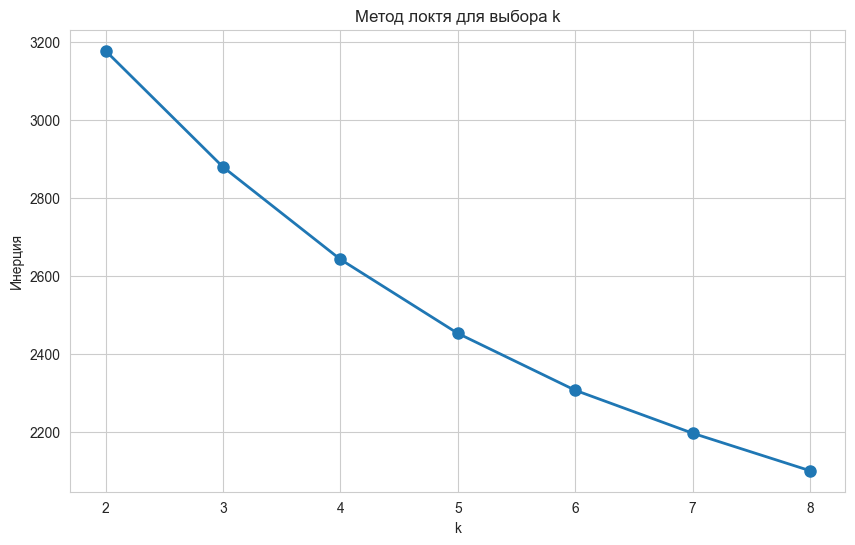

Оптимальное k = 3


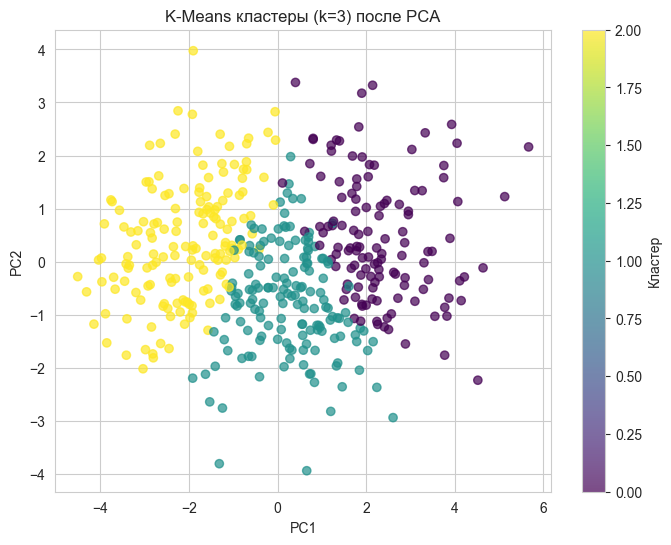

Средние значения признаков по кластерам:
              age       sex       bmi        bp        s1        s2        s3  \
cluster                                                                         
0        0.018170  0.012551  0.025421  0.022322  0.051466  0.049246 -0.024168   
1        0.012717  0.017707  0.013744  0.015254 -0.017682 -0.012247 -0.016553   
2       -0.027172 -0.027749 -0.033943 -0.033010 -0.022922 -0.026635  0.035778   

               s4        s5        s6  
cluster                                
0        0.050619  0.043166  0.032192  
1       -0.000849  0.003491  0.006894  
2       -0.039192 -0.037663 -0.032406  


In [10]:
# #PROC: K-Means кластеризация
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Масштабирование (обязательно для K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Метод локтя
inertias = []
k_range = range(2, 9)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('k')
plt.ylabel('Инерция')
plt.title('Метод локтя для выбора k')
plt.grid(True)
plt.show()

optimal_k = 3  # по графику локтя
print(f"Оптимальное k = {optimal_k}")

# Кластеризация с оптимальным k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Визуализация через PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means кластеры (k={optimal_k}) после PCA')
plt.show()

# Анализ средних по кластерам
df['cluster'] = clusters
cluster_means = df.groupby('cluster')[data.feature_names].mean()
print("Средние значения признаков по кластерам:")
print(cluster_means)

Интерпретация результатов (на пальцах):
Посмотрев на таблицу cluster_means, можно увидеть примерно такую картину:

Кластер 0: Пациенты с высокими показателями s1–s6 (анализы крови) и высоким bmi. Это, скорее всего, группа высокого риска с максимальным прогрессом диабета.

Кластер 1: Пациенты со значениями, близкими к средним. Это типичная "средняя" группа.

Кластер 2: Пациенты с низкими показателями по большинству признаков. Это группа низкого риска, болезнь у которых прогрессирует медленнее.